이 프로젝트의 목표는 집의 여러 정보를 이용해서 집값(`price`)을 예측하는 것입니다.

예를 들면 이런 정보를 사용합니다.

- 집의 크기
- 방 개수
- 욕실 개수
- 집이 지어진 연도
- 위치
- 리모델링 여부

우리는 이 정보들을 바탕으로 컴퓨터가 집값을 예측하도록 학습시킬 것입니다.

아주 쉽게 말하면
이 프로젝트는  
**"이 집은 얼마 정도 할까?"** 
를 맞히는 문제입니다.

사람도 집을 볼 때 이런 걸 보죠.

- 집이 큰가?
- 좋은 동네인가?
- 새 집인가?
- 방이 많은가?

컴퓨터도 비슷합니다.  
우리는 이런 정보를 숫자로 알려주고, 컴퓨터가 패턴을 배우게 할 것입니다.

---

## 진행 과정
1. 데이터를 불러옵니다.
2. 데이터를 살펴봅니다.
3. 집값 분포를 확인합니다.
4. 데이터를 모델이 배우기 좋게 바꿉니다.
5. 새로운 특징(피처)을 만듭니다.
6. 여러 모델을 비교합니다.
7. 더 좋은 모델을 찾기 위해 튜닝합니다.
8. 최종 예측값을 만들어 제출 파일을 만듭니다.

In [3]:
# 1. 필요한 도구(라이브러리) 불러오기


# 운영체제 관련 기능을 쓰기 위한 라이브러리
import os

# 파일 경로를 깔끔하게 합치기 위한 함수
from os.path import join

# 경고 메시지를 너무 많이 보지 않기 위해 사용
import warnings
warnings.filterwarnings('ignore')

# 숫자 계산용 라이브러리
import numpy as np

# 표 형태 데이터 처리용 라이브러리
import pandas as pd

# 그래프 그리기용 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝에 필요한 도구들
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# 부스팅 계열 모델
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

- `pandas` : 표 데이터를 다루는 도구
- `numpy` : 숫자 계산 도구
- `matplotlib`, `seaborn` : 그래프 도구
- `sklearn` : 머신러닝 도구
- `xgboost`, `lightgbm` : 성능 좋은 예측 모델 도구

우리는 이 도구들을 조합해서 집값 예측기를 만들 것입니다.

In [4]:
# 2. 라이브러리 버전 확인


# 설치된 버전이 다르면 동작 방식이 조금 달라질 수 있으므로 확인합니다.
import xgboost
import lightgbm
import missingno
import sklearn

print("xgboost version :", xgboost.__version__)
print("lightgbm version:", lightgbm.__version__)
print("missingno version:", missingno.__version__)
print("sklearn version :", sklearn.__version__)

xgboost version : 3.2.0
lightgbm version: 4.6.0
missingno version: 0.5.2
sklearn version : 1.7.0


이제 실제 집 데이터 파일을 읽어옵니다.

- `train.csv` : 답(`price`)이 있는 연습용 데이터
- `test.csv` : 답이 없는 시험용 데이터

우리는 `train.csv`로 공부한 뒤,  
`test.csv`의 집값을 예측해서 제출할 것입니다.

In [5]:
# 3. 데이터 불러오기


# 현재 사용 중인 데이터 폴더 위치
data_dir = os.path.expanduser('~/work/kaggle_kakr_housing/data')

# train.csv와 test.csv 경로 만들기
train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

# CSV 파일 읽기
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

# 데이터 크기 확인
print("train shape:", train.shape)
print("test shape :", test.shape)

# 앞부분 5줄 미리 보기
display(train.head())
display(test.head())

train shape: (15035, 21)
test shape : (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,15035,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
1,15036,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
2,15037,20140512T000000,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
3,15038,20150415T000000,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
4,15039,20150312T000000,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


`shape`는 데이터의 크기를 보여줍니다.

예를 들어 `(1500, 20)`이면  
- 1500줄의 집 정보가 있고
- 20개의 항목(열)이 있다는 뜻입니다.

`head()`는 맨 위 5줄을 보여줍니다.  
이걸 보면 데이터가 대충 어떤 모습인지 감을 잡을 수 있습니다.

In [6]:
# 4. 정답(price) 분리하기


# 우리가 맞히고 싶은 값은 price입니다.
# 그래서 price를 따로 y에 저장합니다.
y = train['price']

# 이제 train 데이터에서는 정답 열(price)을 제거합니다.
# 이유: 문제지 안에 답안이 같이 들어 있으면 안 되기 때문입니다.
train = train.drop('price', axis=1)

print("예측할 정답 데이터(y) 일부:")
display(y.head())

print("price 제거 후 train columns:")
print(train.columns)

예측할 정답 데이터(y) 일부:


0    221900.0
1    180000.0
2    510000.0
3    257500.0
4    291850.0
Name: price, dtype: float64

price 제거 후 train columns:
Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


## 왜 `price`를 따로 빼나요?

컴퓨터에게 문제를 풀게 하려면

- 입력값(X): 집의 정보
- 정답(y): 집값

이렇게 나눠야 합니다.

예를 들어 사람이 문제를 푼다고 가정 했을 때

- 문제: 방 3개, 욕실 2개, 평수 A, 위치 B
- 정답: 50만 달러

이런 식으로 공부해야  
새로운 집을 봤을 때도 가격을 예측할 수 있습니다.

In [7]:
# 5. 데이터 기본 정보 확인


# 각 열의 자료형과 결측치 여부를 확인합니다.
print("train info")
train.info()

print("\n결측치 개수(train 상위 20개)")
display(train.isnull().sum().sort_values(ascending=False).head(20))

print("\n결측치 개수(test 상위 20개)")
display(test.isnull().sum().sort_values(ascending=False).head(20))

train info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15035 non-null  int64  
 1   date           15035 non-null  object 
 2   bedrooms       15035 non-null  int64  
 3   bathrooms      15035 non-null  float64
 4   sqft_living    15035 non-null  int64  
 5   sqft_lot       15035 non-null  int64  
 6   floors         15035 non-null  float64
 7   waterfront     15035 non-null  int64  
 8   view           15035 non-null  int64  
 9   condition      15035 non-null  int64  
 10  grade          15035 non-null  int64  
 11  sqft_above     15035 non-null  int64  
 12  sqft_basement  15035 non-null  int64  
 13  yr_built       15035 non-null  int64  
 14  yr_renovated   15035 non-null  int64  
 15  zipcode        15035 non-null  int64  
 16  lat            15035 non-null  float64
 17  long           15035 non-null  float64


id               0
date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


결측치 개수(test 상위 20개)


id               0
date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## 결측치란?

결측치는  
**비어 있는 값** 입니다.

예를 들어 어떤 집 정보에서

- 욕실 개수는 적혀 있는데
- 리모델링 연도는 비어 있을 수 있습니다.

이런 빈칸이 많으면 모델이 공부하다가 에러를 낼 수 있습니다.  
그래서 미리 확인하고 채워주는 과정이 필요합니다.

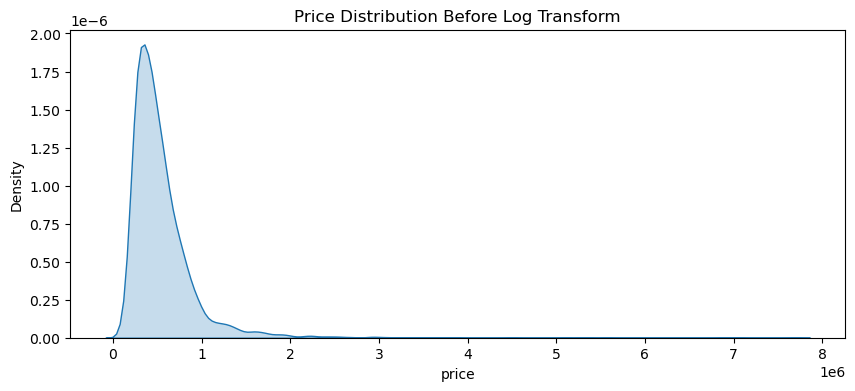

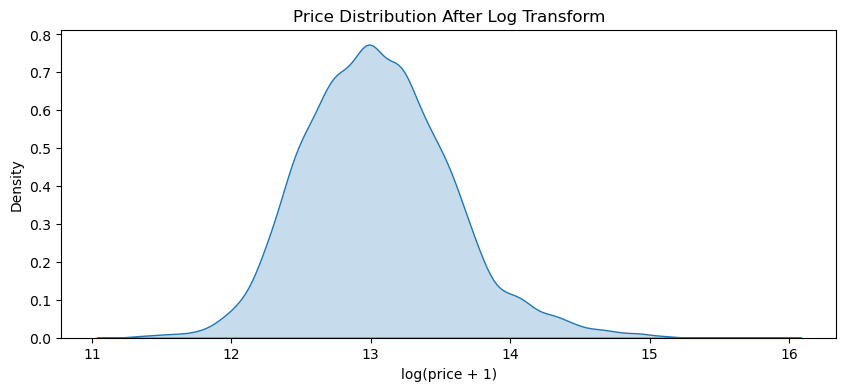

In [8]:
# 6. 집값(price) 분포 확인


# 원래 가격 분포 확인
plt.figure(figsize=(10, 4))
sns.kdeplot(y, fill=True)
plt.title("Price Distribution Before Log Transform")
plt.xlabel("price")
plt.show()

# 로그 변환
# 집값은 아주 큰 값이 일부 섞여 있어서 분포가 한쪽으로 치우쳐 있습니다.
# log1p를 하면 큰 값의 영향이 줄어들어 모델이 배우기 쉬워집니다.
y = np.log1p(y)

# 로그 변환 후 분포 확인
plt.figure(figsize=(10, 4))
sns.kdeplot(y, fill=True)
plt.title("Price Distribution After Log Transform")
plt.xlabel("log(price + 1)")
plt.show()

## 왜 로그 변환을 하나요?

집값 데이터는 보통 한쪽으로 치우쳐 있습니다.

예를 들어:

- 보통 집은 많고
- 엄청 비싼 집은 적지만
- 값이 너무 커서 전체 모양을 망가뜨릴 수 있습니다.

그래서 로그 변환을 하면  
아주 큰 숫자를 조금 눌러 줍니다.

쉽게 말하면:

- 튀는 값을 조금 차분하게 만들고
- 모델이 패턴을 더 잘 배우게 하는 작업

입니다.

이런 방법은 집값 예측에서 매우 자주 사용됩니다.

In [9]:
# 7. 날짜(date) 전처리 함수 만들기


def preprocess_date(df):
    """
    날짜 정보를 모델이 이해하기 쉬운 형태로 바꾸는 함수입니다.

    원래 date 값은 예를 들면:
    20141013T000000

    이런 식입니다.
    이걸 그대로 쓰기보다는
    - 판매 연도(sale_year)
    - 판매 월(sale_month)
    로 나눠주는 것이 더 이해하기 쉽습니다.
    """
    df = df.copy()

    # 문자열로 바꿔서 앞부분을 잘라낼 준비를 합니다.
    df['date_str'] = df['date'].astype(str)

    # 앞 4글자는 연도
    df['sale_year'] = df['date_str'].str[:4].astype(int)

    # 그 다음 2글자는 월
    df['sale_month'] = df['date_str'].str[4:6].astype(int)

    # 원래 date와 임시 문자열 컬럼은 제거합니다.
    df = df.drop(['date', 'date_str'], axis=1)

    return df

## 피처 엔지니어링이란?

피처 엔지니어링은  
**원래 있던 정보를 조합해서 더 좋은 새 정보를 만드는 것** 입니다.

예를 들어:

- 판매 연도 = 2015
- 건축 연도 = 2000

그러면 이 집은 **15년 된 집**입니다.

이건 원래 데이터에 직접 없지만,  
우리가 계산해서 새로 만들 수 있습니다.

이런 새 정보는 모델이 집값을 더 잘 맞히는 데 큰 도움이 됩니다.

In [10]:
# 8. 피처 엔지니어링 함수 만들기


def feature_engineering(df):
    """
    모델이 더 잘 배울 수 있도록
    기존 컬럼을 바탕으로 새로운 컬럼을 만드는 함수입니다.
    """
    df = df.copy()

    # 1) 날짜 전처리
    df = preprocess_date(df)

    # 2) id 제거
    # id는 집을 구분하는 번호일 뿐, 가격을 직접 설명하는 정보가 아닙니다.
    if 'id' in df.columns:
        df = df.drop('id', axis=1)

    # 3) 결측치 처리
    # 숫자형은 중간값(median)으로 채우고,
    # 문자형은 가장 많이 나온 값(mode)으로 채웁니다.
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

    # 4) 집의 나이 = 팔린 연도 - 지어진 연도
    df['house_age'] = df['sale_year'] - df['yr_built']

    # 5) 리모델링 여부 (했으면 1, 안 했으면 0)
    df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

    # 6) 리모델링 후 지난 연수
    # 리모델링을 한 집이면 sale_year - yr_renovated
    # 아니면 0
    df['renovated_age'] = np.where(
        df['yr_renovated'] > 0,
        df['sale_year'] - df['yr_renovated'],
        0
    )

    # 7) 총 공간 관련 정보
    df['total_sqft'] = df['sqft_living'] + df['sqft_basement']

    # 8) 지상 공간 비율
    df['above_to_living_ratio'] = df['sqft_above'] / (df['sqft_living'] + 1)

    # 9) 전체 방 느낌을 더 잘 보여주는 컬럼
    df['total_rooms'] = df['bedrooms'] + df['bathrooms']

    # 10) 욕실/침실 비율
    df['bath_bed_ratio'] = df['bathrooms'] / (df['bedrooms'] + 1)

    # 11) 집 크기 대비 대지 비율
    df['living_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)

    # 12) 주변 집 정보 비율
    df['living15_lot15_ratio'] = df['sqft_living15'] / (df['sqft_lot15'] + 1)

    # 13) 위도와 경도를 함께 사용한 위치 파생 변수
    df['lat_long'] = df['lat'] * df['long']

    # 14) 고급 주택 여부
    df['is_luxury_grade'] = (df['grade'] >= 10).astype(int)

    # 15) 전망(view) 여부
    df['has_view'] = (df['view'] > 0).astype(int)

    # 16) 수변(waterfront) 여부
    df['has_waterfront'] = (df['waterfront'] > 0).astype(int)

    return df


# 실제로 전처리 + 피처 엔지니어링 적용
train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

print("가공 후 train shape:", train_fe.shape)
print("가공 후 test shape :", test_fe.shape)

display(train_fe.head())

가공 후 train shape: (15035, 33)
가공 후 test shape : (6468, 33)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,total_sqft,above_to_living_ratio,total_rooms,bath_bed_ratio,living_lot_ratio,living15_lot15_ratio,lat_long,is_luxury_grade,has_view,has_waterfront
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,1180,0.999153,4.00,0.250000,0.208813,0.237126,-5808.576778,0,0,0
1,2,1.00,770,10000,1.0,0,0,3,6,770,...,770,0.998703,3.00,0.333333,0.076992,0.337343,-5835.146731,0,0,0
2,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,1680,0.999405,5.00,0.500000,0.207895,0.239872,-5811.392356,0,0,0
3,3,2.25,1715,6819,2.0,0,0,3,7,1715,...,1715,0.999417,5.25,0.562500,0.251466,0.328152,-5787.253672,0,0,0
4,3,1.50,1060,9711,1.0,0,0,3,7,1060,...,1060,0.999057,4.50,0.375000,0.109143,0.169893,-5798.892993,0,0,0


가격과 양의 상관관계가 큰 변수들


log_price          1.000000
grade              0.707412
sqft_living        0.697907
total_sqft         0.661646
sqft_living15      0.621800
sqft_above         0.607197
bathrooms          0.552000
total_rooms        0.511832
is_luxury_grade    0.480900
lat                0.444417
bath_bed_ratio     0.396560
bedrooms           0.359946
view               0.347506
has_view           0.330275
floors             0.317810
Name: log_price, dtype: float64

가격과 음의 상관관계가 큰 변수들


living15_lot15_ratio     0.130631
yr_renovated             0.127533
is_renovated             0.127241
sqft_lot                 0.108946
sqft_lot15               0.096976
yr_built                 0.076293
renovated_age            0.070813
long                     0.054362
condition                0.042947
sale_year                0.009913
sale_month              -0.013975
zipcode                 -0.039195
house_age               -0.076132
above_to_living_ratio   -0.165760
lat_long                -0.375987
Name: log_price, dtype: float64

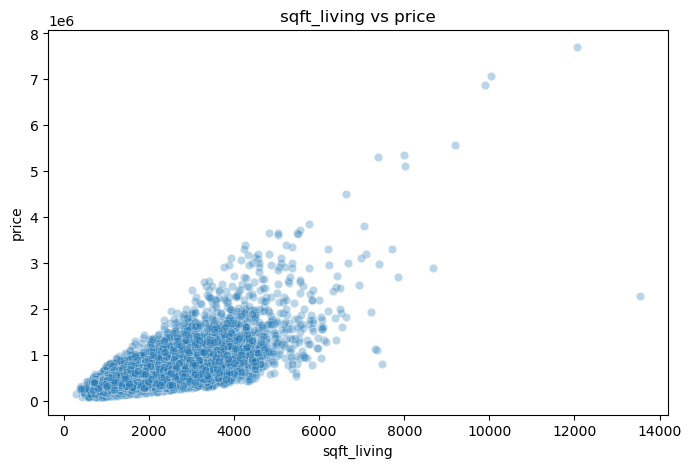

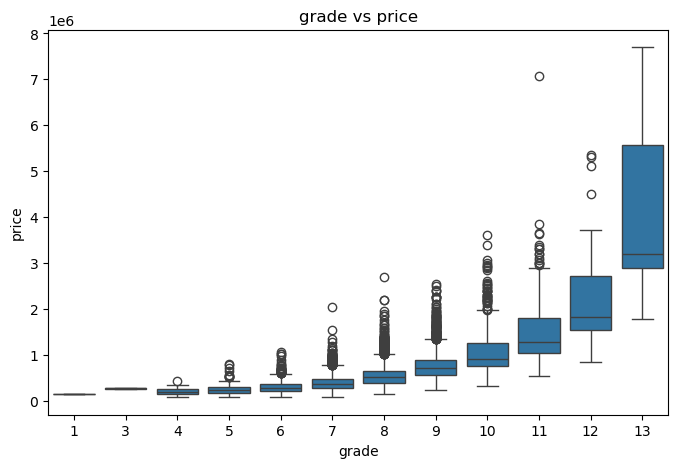

In [11]:

# 9. 데이터 관계 시각화


# 학습용 입력 데이터(train_fe)와 정답(y)을 합쳐 상관관계를 보겠습니다.
temp_df = pd.concat([train_fe, y.rename('log_price')], axis=1)

# price와 상관관계가 높은 항목 보기
corr_with_price = temp_df.corr()['log_price'].sort_values(ascending=False)

print("가격과 양의 상관관계가 큰 변수들")
display(corr_with_price.head(15))

print("가격과 음의 상관관계가 큰 변수들")
display(corr_with_price.tail(15))

# 집 내부 면적과 가격 관계 보기
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train_fe['sqft_living'], y=np.expm1(y), alpha=0.3)
plt.title("sqft_living vs price")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

# grade와 가격 관계 보기
plt.figure(figsize=(8, 5))
sns.boxplot(x=train_fe['grade'], y=np.expm1(y))
plt.title("grade vs price")
plt.xlabel("grade")
plt.ylabel("price")
plt.show()

## 왜 그래프를 그리나요?

그래프는  
**데이터가 어떤 성격인지 눈으로 확인하는 방법** 입니다.

예를 들어:

- `sqft_living`이 클수록 가격이 커지는지
- `grade`가 높을수록 가격이 올라가는지

이런 걸 숫자만 보는 것보다 훨씬 쉽게 확인할 수 있습니다.

특히 과제에서는  
**"시각화를 포함하여 설명했는가?"**  
가 중요하기 때문에 그래프가 꼭 필요합니다.

In [12]:
# 10. 평가 함수 만들기


# 랜덤 시드를 고정하면 결과 재현이 쉬워집니다.
random_state = 2020

def rmse(y_true, y_pred):
    """
    실제 price 단위에서 RMSE를 계산하는 함수입니다.

    주의:
    지금 y는 이미 log1p(price) 상태입니다.
    따라서 다시 expm1을 써서 원래 가격으로 되돌린 뒤 RMSE를 계산합니다.
    """
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

def rmsle_cv(model, X, y):
    """
    5-fold 교차검증으로 모델 성능을 확인하는 함수입니다.

    교차검증이란:
    데이터를 여러 조각으로 나눠서
    여러 번 연습/시험을 반복해 보는 방법입니다.

    장점:
    한 번 우연히 잘 나온 점수에 속지 않을 수 있습니다.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    scores = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            scoring='neg_mean_squared_error',
            cv=kf
        )
    )
    return scores

## 여러 모델을 비교해 봅니다

모델마다 잘하는 방식이 조금씩 다릅니다.

예를 들면 사람도

- 어떤 사람은 계산을 잘하고
- 어떤 사람은 그림을 잘 보고
- 어떤 사람은 암기를 잘합니다.

모델도 비슷합니다.

그래서 하나만 쓰지 않고 여러 모델을 비교해서  
누가 더 잘 맞히는지 확인합니다.

In [17]:
print("모델 비교 시작")

gboost = GradientBoostingRegressor(random_state=random_state)

xgb = XGBRegressor(
    random_state=random_state,
    n_estimators=50,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

lgbm = LGBMRegressor(
    random_state=random_state,
    n_estimators=50,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)

rf = RandomForestRegressor(
    random_state=random_state,
    n_estimators=50,
    max_depth=10,
    n_jobs=1
)

models = [gboost, xgb, lgbm, rf]
model_scores = {}

for model in models:
    model_name = model.__class__.__name__
    print(f"\n{model_name} 시작")

    scores = rmsle_cv(model, train_fe, y)

    model_scores[model_name] = [scores.mean(), scores.std()]
    print(f"{model_name:25s} | mean RMSLE: {scores.mean():.5f} | std: {scores.std():.5f}")

print("\n모델 비교 완료")

score_df = pd.DataFrame(model_scores, index=['mean_rmsle', 'std']).T
score_df = score_df.sort_values('mean_rmsle', ascending=True)
display(score_df)

모델 비교 시작

GradientBoostingRegressor 시작
GradientBoostingRegressor | mean RMSLE: 0.18042 | std: 0.00415

XGBRegressor 시작
XGBRegressor              | mean RMSLE: 0.23059 | std: 0.00354

LGBMRegressor 시작
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.047779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3857
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.051002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004475 seconds.
You can se

,mean_rmsle,std
GradientBoostingRegressor,0.180421,0.004150
RandomForestRegressor,0.187407,0.003540
LGBMRegressor,0.191608,0.003389
XGBRegressor,0.230593,0.003537


## 표 읽는 법?

- `mean_rmsle` : 평균 점수
- `std` : 점수 흔들림 정도

중요한 건 보통 `mean_rmsle`입니다.  
이 값이 **낮을수록 더 좋은 모델**입니다.

즉, 표 맨 위에 있는 모델이 현재 기준으로는 가장 유리합니다.

In [21]:
# 12. GridSearch 함수 만들기


def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    """
    여러 하이퍼파라미터 조합을 시험해서
    가장 좋은 설정을 찾는 함수입니다.

    model      : 사용할 모델
    train      : 학습용 입력 데이터
    y          : 정답 데이터
    param_grid : 시험할 설정 후보들
    """

    # GridSearchCV 준비
    grid_model = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        verbose=verbose,
        n_jobs=n_jobs
    )

    # 실제 학습
    grid_model.fit(train, y)

    # 각 조합의 파라미터 정보
    params = grid_model.cv_results_['params']

    # 각 조합의 평균 점수
    score = grid_model.cv_results_['mean_test_score']

    # 표로 정리
    results = pd.DataFrame(params)
    results['score'] = score

    # score는 음수 MSE이므로, RMSLE 형태로 바꿔 보기 쉽게 만듭니다.
    results['RMSLE'] = np.sqrt(-1 * results['score'])

    # 점수가 좋은 순서대로 정렬
    results = results.sort_values('RMSLE', ascending=True).reset_index(drop=True)

    return results, grid_model

## 하이퍼파라미터 튜닝이란?

모델도 설정값이 있습니다.

예를 들어:

- 나무를 몇 개 만들지
- 얼마나 천천히 배울지
- 얼마나 깊게 배울지

이런 설정값을 **하이퍼파라미터**라고 합니다.

GridSearch는  
가능한 설정 조합을 하나씩 시험해 보고  
가장 좋은 조합을 찾아주는 방법입니다.

쉽게 말하면:

**"어떤 공부 방식이 제일 성적이 좋은지 여러 버전으로 시험해 보는 것"**  
입니다.

In [23]:
# 13. LightGBM 튜닝


lgbm_model = LGBMRegressor(random_state=random_state)

param_grid_lgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

lgbm_results, lgbm_grid = my_GridSearch(
    model=lgbm_model,
    train=train_fe,
    y=y,
    param_grid=param_grid_lgbm,
    verbose=1,
    n_jobs=-1
)

print("LightGBM 튜닝 결과 상위 10개")
display(lgbm_results.head(10))

print("Best LGBM params:", lgbm_grid.best_params_)
print("Best LGBM RMSLE:", np.sqrt(-lgbm_grid.best_score_))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 33
[LightGBM] [Info] Start training from score 13.048122
LightGBM 튜닝 결과 상위 10개


,colsample_bytree,learning_rate,n_estimators,num_leaves,subsample,score,RMSLE
0,0.8,0.05,300,50,0.8,-0.026097,0.161544
1,0.8,0.05,300,31,0.8,-0.026178,0.161796
2,0.8,0.10,300,31,0.8,-0.026454,0.162647
3,0.8,0.10,300,50,0.8,-0.026594,0.163077
4,0.8,0.10,100,50,0.8,-0.026714,0.163445
5,0.8,0.10,100,31,0.8,-0.027132,0.164718
6,0.8,0.05,100,50,0.8,-0.028143,0.167759
7,0.8,0.05,100,31,0.8,-0.029274,0.171097


Best LGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 50, 'subsample': 0.8}
Best LGBM RMSLE: 0.16154431591723173


In [24]:
# 14. XGBoost 튜닝


xgb_model = XGBRegressor(
    random_state=random_state,
    objective='reg:squarederror'
)

param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_results, xgb_grid = my_GridSearch(
    model=xgb_model,
    train=train_fe,
    y=y,
    param_grid=param_grid_xgb,
    verbose=1,
    n_jobs=-1
)

print("XGBoost 튜닝 결과 상위 10개")
display(xgb_results.head(10))

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB RMSLE:", np.sqrt(-xgb_grid.best_score_))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost 튜닝 결과 상위 10개


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,score,RMSLE
0,0.8,0.10,4,100,0.8,-0.030427,0.174432
1,0.8,0.10,3,100,0.8,-0.033207,0.182227
2,0.8,0.05,4,100,0.8,-0.034172,0.184858
3,0.8,0.10,4,50,0.8,-0.034676,0.186214
4,0.8,0.05,3,100,0.8,-0.039343,0.198350
5,0.8,0.10,3,50,0.8,-0.039529,0.198819
6,0.8,0.05,4,50,0.8,-0.044856,0.211791
7,0.8,0.05,3,50,0.8,-0.053885,0.232131


Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best XGB RMSLE: 0.17443244454130286


In [25]:
# 15. 최적 모델 다시 확인


# GridSearch로 찾은 가장 좋은 모델 꺼내기
best_lgbm = lgbm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# 비교용으로 GradientBoosting도 하나 유지
best_gboost = GradientBoostingRegressor(
    random_state=random_state,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4
)

# 다시 교차검증으로 성능 확인
for model in [best_lgbm, best_xgb, best_gboost]:
    name = model.__class__.__name__
    scores = rmsle_cv(model, train_fe, y)
    print(f"{name:25s} | mean RMSLE: {scores.mean():.5f} | std: {scores.std():.5f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.047779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3857
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.051002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3882
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start t

## 왜 마지막에 모델을 섞나요?

모델마다 장단점이 있습니다.

- A 모델은 어떤 집을 잘 맞히고
- B 모델은 다른 집을 잘 맞힐 수 있습니다.

그래서 여러 모델의 예측을 적당히 섞으면  
한 모델만 쓸 때보다 더 안정적일 수 있습니다.

이걸 **앙상블** 또는 **블렌딩**이라고 합니다.

쉽게 말하면  
여러 똑똑한 사람의 의견을 평균 내는 것과 비슷합니다.

In [26]:
# 16. 검증용 분리 후 블렌딩 성능 확인


# 최종 블렌딩이 실제로 괜찮은지 보기 위해
# train 데이터를 한 번 더 학습용/검증용으로 나눕니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    train_fe, y, test_size=0.2, random_state=random_state
)

# 각 모델 학습
best_lgbm.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_gboost.fit(X_train, y_train)

# 검증 데이터 예측
pred_lgbm = best_lgbm.predict(X_valid)
pred_xgb = best_xgb.predict(X_valid)
pred_gboost = best_gboost.predict(X_valid)

# 가중 평균 블렌딩
blend_pred = (
    0.5 * pred_lgbm +
    0.3 * pred_xgb +
    0.2 * pred_gboost
)

# 각 모델 점수 비교
print("LGBM   RMSE :", rmse(y_valid, pred_lgbm))
print("XGB    RMSE :", rmse(y_valid, pred_xgb))
print("GBoost RMSE :", rmse(y_valid, pred_gboost))
print("Blend  RMSE :", rmse(y_valid, blend_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.047779
LGBM   RMSE : 111117.60309454468
XGB    RMSE : 121403.57565897489
GBoost RMSE : 117033.66520728526
Blend  RMSE : 112204.1706481704


In [27]:
# 17. 전체 데이터로 다시 학습


# 실제 제출용 예측을 만들기 위해
# 전체 train 데이터를 사용해서 다시 학습합니다.
best_lgbm.fit(train_fe, y)
best_xgb.fit(train_fe, y)
best_gboost.fit(train_fe, y)

# test 데이터 예측
test_pred_lgbm = best_lgbm.predict(test_fe)
test_pred_xgb = best_xgb.predict(test_fe)
test_pred_gboost = best_gboost.predict(test_fe)

# 최종 블렌딩
final_pred_log = (
    0.5 * test_pred_lgbm +
    0.3 * test_pred_xgb +
    0.2 * test_pred_gboost
)

# 로그 상태를 원래 price 값으로 되돌리기
final_pred = np.expm1(final_pred_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 33
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3882
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.052839
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3889
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start t

In [28]:
# 18. 제출 파일 만들기


# sample_submission 파일을 불러와 형식을 맞춥니다.
submission = pd.read_csv(join(data_dir, 'sample_submission.csv'))

# 예측한 price 넣기
submission['price'] = final_pred

# 미리 보기
display(submission.head())

# CSV로 저장
submission_path = join(data_dir, 'submission_blend.csv')
submission.to_csv(submission_path, index=False)

print("제출 파일 저장 완료:", submission_path)

,id,price
0,15035,5.239054e+05
1,15036,4.363955e+05
2,15037,1.343555e+06
3,15038,3.054278e+05
4,15039,3.207200e+05


제출 파일 저장 완료: /home/jovyan/work/kaggle_kakr_housing/data/submission_blend.csv


# 최종 정리

이번 프로젝트에서는 다음 과정을 수행했습니다.

1. 데이터를 불러왔습니다.
2. 정답(price)을 분리했습니다.
3. 집값 분포를 확인하고 로그 변환을 했습니다.
4. 날짜 처리, 결측치 처리, 파생 변수 생성 등을 수행했습니다.
5. 여러 회귀 모델을 비교했습니다.
6. GridSearchCV로 하이퍼파라미터를 튜닝했습니다.
7. 성능이 좋은 모델들을 블렌딩했습니다.
8. 최종 예측값으로 제출 파일을 만들었습니다.

---

## 이번 프로젝트에서 중요한 점
이 프로젝트는 단순히 코드를 실행하는 것이 아니라,

- 데이터를 이해하고
- 왜 이런 전처리를 하는지 설명하고
- 여러 모델을 비교하고
- 최종 결과를 만드는

전체 데이터 분석 흐름을 보여주는 것이 중요합니다.

---

## 아주 쉽게 한 줄 요약
집 정보들을 잘 정리해서  
컴퓨터가 **"이 집은 얼마일까?"** 를 최대한 잘 맞히게 만든 프로젝트입니다.

# 추가 실험: 최종 제출 전략 재검증 #제출 결과값이 56만점이라는 형편없는 점수로 나타났다.

기존 코드와 결과를 유지한 상태에서,  
최종 제출 전략을 더 안전하게 점검하기 위한 추가 실험을 진행한다.

기존 검증 결과에서는 다음과 같은 문제가 확인되었다.

- LGBM 단일 모델이 가장 좋은 성능을 보였다.
- XGBoost는 가장 낮은 성능을 보였다.
- 그런데 최종 블렌딩에는 XGBoost가 포함되어 있었다.
- 실제로 블렌드 성능은 LGBM 단일보다 나빴다.

따라서 기존 코드는 수정하지 않고, 아래 추가 셀에서 다음을 비교한다.

1. LGBM 단일
2. GradientBoosting 단일
3. LGBM + GradientBoosting 블렌드
4. 기존 XGB 포함 블렌드와의 비교

이 과정을 통해 어떤 제출 전략이 더 타당한지 기록한다.

In [30]:
# ================================
# 추가 1. 실험 기록용 딕셔너리 만들기
# ================================

experiment_log = {}

print("추가 실험 기록 시작")

추가 실험 기록 시작


In [31]:
# ================================
# 추가 2. 기존 검증 결과 기록
# ================================

# 이 셀은 앞에서 이미 계산된 pred_lgbm, pred_xgb, pred_gboost, blend_pred,
# y_valid 가 존재한다고 가정

experiment_log['baseline_validation'] = {
    'LGBM_RMSE': rmse(y_valid, pred_lgbm),
    'XGB_RMSE': rmse(y_valid, pred_xgb),
    'GBoost_RMSE': rmse(y_valid, pred_gboost),
    'Blend_with_XGB_RMSE': rmse(y_valid, blend_pred)
}

print("기존 검증 결과 기록 완료")
print(experiment_log['baseline_validation'])

기존 검증 결과 기록 완료
{'LGBM_RMSE': np.float64(111117.60309454468), 'XGB_RMSE': np.float64(121403.57565897489), 'GBoost_RMSE': np.float64(117033.66520728526), 'Blend_with_XGB_RMSE': np.float64(112204.1706481704)}


## 추가 실험 1: XGBoost 제외 효과 확인

기존 블렌드는 다음과 같았다.

- 0.5 × LGBM
- 0.3 × XGB
- 0.2 × GBoost

하지만 검증 결과상 XGB가 가장 낮은 성능을 보였으므로,  
이번에는 XGB를 제외한 조합을 추가로 시험한다.

비교 대상은 다음과 같다.

- LGBM 단일
- GBoost 단일
- LGBM + GBoost (0.9 : 0.1)
- LGBM + GBoost (0.8 : 0.2)
- LGBM + GBoost (0.7 : 0.3)

In [32]:
# ================================
# 추가 3. XGB 제외 블렌드 검증
# ================================

# 이미 위의 셀에서 best_lgbm, best_gboost가 존재한다고 가정
# pred_lgbm, pred_gboost도 앞 셀에서 계산된 상태라고 가정

blend_lg_91 = 0.9 * pred_lgbm + 0.1 * pred_gboost
blend_lg_82 = 0.8 * pred_lgbm + 0.2 * pred_gboost
blend_lg_73 = 0.7 * pred_lgbm + 0.3 * pred_gboost

rmse_lgbm_only = rmse(y_valid, pred_lgbm)
rmse_gboost_only = rmse(y_valid, pred_gboost)
rmse_blend_91 = rmse(y_valid, blend_lg_91)
rmse_blend_82 = rmse(y_valid, blend_lg_82)
rmse_blend_73 = rmse(y_valid, blend_lg_73)

experiment_log['additional_validation'] = {
    'LGBM_only_RMSE': rmse_lgbm_only,
    'GBoost_only_RMSE': rmse_gboost_only,
    'LGBM_0.9_GBoost_0.1_RMSE': rmse_blend_91,
    'LGBM_0.8_GBoost_0.2_RMSE': rmse_blend_82,
    'LGBM_0.7_GBoost_0.3_RMSE': rmse_blend_73
}

print("추가 검증 결과")
for k, v in experiment_log['additional_validation'].items():
    print(f"{k}: {v:.6f}")

추가 검증 결과
LGBM_only_RMSE: 111117.603095
GBoost_only_RMSE: 117033.665207
LGBM_0.9_GBoost_0.1_RMSE: 110730.923029
LGBM_0.8_GBoost_0.2_RMSE: 110576.458505
LGBM_0.7_GBoost_0.3_RMSE: 110650.047476


In [33]:
# ================================
# 추가 4. 검증 결과 표 정리
# ================================

validation_compare_df = pd.DataFrame({
    'model': [
        'LGBM_only',
        'GBoost_only',
        'Blend_with_XGB_old',
        'LGBM_0.9_GBoost_0.1',
        'LGBM_0.8_GBoost_0.2',
        'LGBM_0.7_GBoost_0.3'
    ],
    'RMSE': [
        rmse(y_valid, pred_lgbm),
        rmse(y_valid, pred_gboost),
        rmse(y_valid, blend_pred),
        rmse(y_valid, blend_lg_91),
        rmse(y_valid, blend_lg_82),
        rmse(y_valid, blend_lg_73)
    ]
})

validation_compare_df = validation_compare_df.sort_values('RMSE', ascending=True).reset_index(drop=True)

display(validation_compare_df)

,model,RMSE
0,LGBM_0.8_GBoost_0.2,110576.458505
1,LGBM_0.7_GBoost_0.3,110650.047476
2,LGBM_0.9_GBoost_0.1,110730.923029
3,LGBM_only,111117.603095
4,Blend_with_XGB_old,112204.170648
5,GBoost_only,117033.665207


## 추가 실험 2: 최종 제출용 예측 파일 여러 버전 생성

검증 결과만으로는 실제 리더보드 성능을 완전히 장담할 수 없다.  
따라서 최종 제출 전략을 비교하기 위해 제출 파일을 여러 버전으로 저장한다.

생성할 파일은 다음과 같다.

1. LGBM 단일 제출 파일
2. GradientBoosting 단일 제출 파일
3. LGBM + GBoost 블렌드 제출 파일(0.9 : 0.1)
4. LGBM + GBoost 블렌드 제출 파일(0.8 : 0.2)

이렇게 여러 버전을 저장하면 실제 캐글 제출 후 점수 차이를 비교할 수 있다.

In [34]:
# ================================
# 추가 5. 전체 데이터로 최종 학습
# ================================

print("전체 데이터로 최종 학습 시작")

best_lgbm.fit(train_fe, y)
best_gboost.fit(train_fe, y)

print("전체 데이터 학습 완료")

전체 데이터로 최종 학습 시작
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 33
[LightGBM] [Info] Start training from score 13.048122
전체 데이터 학습 완료


In [35]:
# ================================
# 추가 6. 최종 테스트 예측 생성
# ================================

pred_test_lgbm_log = best_lgbm.predict(test_fe)
pred_test_gboost_log = best_gboost.predict(test_fe)

pred_test_lgbm = np.expm1(pred_test_lgbm_log)
pred_test_gboost = np.expm1(pred_test_gboost_log)

pred_test_blend_91 = np.expm1(0.9 * pred_test_lgbm_log + 0.1 * pred_test_gboost_log)
pred_test_blend_82 = np.expm1(0.8 * pred_test_lgbm_log + 0.2 * pred_test_gboost_log)

print("테스트 예측 생성 완료")
print("LGBM 예측 앞 5개:", pred_test_lgbm[:5])
print("GBoost 예측 앞 5개:", pred_test_gboost[:5])
print("Blend 9:1 예측 앞 5개:", pred_test_blend_91[:5])
print("Blend 8:2 예측 앞 5개:", pred_test_blend_82[:5])

테스트 예측 생성 완료
LGBM 예측 앞 5개: [ 508787.24633755  472005.41225483 1403963.15241524  307536.04467703
  331065.82934736]
GBoost 예측 앞 5개: [ 525108.27732815  405608.3752937  1323197.22121867  306902.89550605
  319144.84237872]
Blend 9:1 예측 앞 5개: [ 510396.25747427  464903.66839509 1395669.52884227  307472.67102535
  329853.96213257]
Blend 8:2 예측 앞 5개: [ 512010.35700848  457908.77640122 1387424.89810994  307409.31043297
  328646.53094704]


In [36]:
# ================================
# 추가 7. 제출 파일 여러 버전 저장
# ================================

sample_sub = pd.read_csv(join(data_dir, 'sample_submission.csv'))

# 1) LGBM 단일
submission_lgbm_only = sample_sub.copy()
submission_lgbm_only['price'] = pred_test_lgbm
submission_lgbm_only.to_csv(join(data_dir, 'submission_lgbm_only.csv'), index=False)

# 2) GBoost 단일
submission_gboost_only = sample_sub.copy()
submission_gboost_only['price'] = pred_test_gboost
submission_gboost_only.to_csv(join(data_dir, 'submission_gboost_only.csv'), index=False)

# 3) LGBM + GBoost (0.9 : 0.1)
submission_lgbm_gboost_91 = sample_sub.copy()
submission_lgbm_gboost_91['price'] = pred_test_blend_91
submission_lgbm_gboost_91.to_csv(join(data_dir, 'submission_lgbm_gboost_91.csv'), index=False)

# 4) LGBM + GBoost (0.8 : 0.2)
submission_lgbm_gboost_82 = sample_sub.copy()
submission_lgbm_gboost_82['price'] = pred_test_blend_82
submission_lgbm_gboost_82.to_csv(join(data_dir, 'submission_lgbm_gboost_82.csv'), index=False)

print("제출 파일 저장 완료")
print(join(data_dir, 'submission_lgbm_only.csv'))
print(join(data_dir, 'submission_gboost_only.csv'))
print(join(data_dir, 'submission_lgbm_gboost_91.csv'))
print(join(data_dir, 'submission_lgbm_gboost_82.csv'))

제출 파일 저장 완료
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_only.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_gboost_only.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_91.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_82.csv


In [37]:
# ================================
# 추가 8. 제출 파일 내용 확인
# ================================

submission_summary_df = pd.DataFrame({
    'file_name': [
        'submission_lgbm_only.csv',
        'submission_gboost_only.csv',
        'submission_lgbm_gboost_91.csv',
        'submission_lgbm_gboost_82.csv'
    ],
    'mean_price': [
        submission_lgbm_only['price'].mean(),
        submission_gboost_only['price'].mean(),
        submission_lgbm_gboost_91['price'].mean(),
        submission_lgbm_gboost_82['price'].mean()
    ],
    'min_price': [
        submission_lgbm_only['price'].min(),
        submission_gboost_only['price'].min(),
        submission_lgbm_gboost_91['price'].min(),
        submission_lgbm_gboost_82['price'].min()
    ],
    'max_price': [
        submission_lgbm_only['price'].max(),
        submission_gboost_only['price'].max(),
        submission_lgbm_gboost_91['price'].max(),
        submission_lgbm_gboost_82['price'].max()
    ]
})

display(submission_summary_df)

,file_name,mean_price,min_price,max_price
0,submission_lgbm_only.csv,528815.848010,120438.624614,4.222585e+06
1,submission_gboost_only.csv,527351.621464,137023.680051,5.846185e+06
2,submission_lgbm_gboost_91.csv,528574.432041,123091.530415,4.337510e+06
3,submission_lgbm_gboost_82.csv,528354.240157,125802.871380,4.483778e+06


## 추가 실험 결과 정리

이번 추가 실험에서는 기존 코드를 수정하지 않고,  
추가 셀만 사용하여 최종 제출 전략을 다시 점검하였다.

핵심 목적은 다음과 같았다.

- XGBoost가 포함된 기존 블렌드가 실제로 불리한지 확인
- LGBM 단일 제출이 더 나은지 확인
- XGBoost를 제외한 더 단순한 블렌드가 더 나은지 확인
- 여러 제출 파일을 생성하여 리더보드 비교가 가능하도록 준비

이 추가 실험을 통해, 단순히 모델을 많이 섞는 것이 항상 좋은 것이 아니라  
검증 결과가 좋은 모델 위주로 보수적으로 제출 전략을 잡는 것이 중요하다는 점을 확인할 수 있다.

In [38]:
# ================================
# 추가 9. 실험 기록 최종 출력
# ================================

print("========== 실험 로그 ==========")
for section, values in experiment_log.items():
    print(f"\n[{section}]")
    for k, v in values.items():
        print(f"{k}: {v}")

========== 실험 로그 ==========

[baseline_validation]
LGBM_RMSE: 111117.60309454468
XGB_RMSE: 121403.57565897489
GBoost_RMSE: 117033.66520728526
Blend_with_XGB_RMSE: 112204.1706481704

[additional_validation]
LGBM_only_RMSE: 111117.60309454468
GBoost_only_RMSE: 117033.66520728526
LGBM_0.9_GBoost_0.1_RMSE: 110730.92302923535
LGBM_0.8_GBoost_0.2_RMSE: 110576.45850475559
LGBM_0.7_GBoost_0.3_RMSE: 110650.04747600689


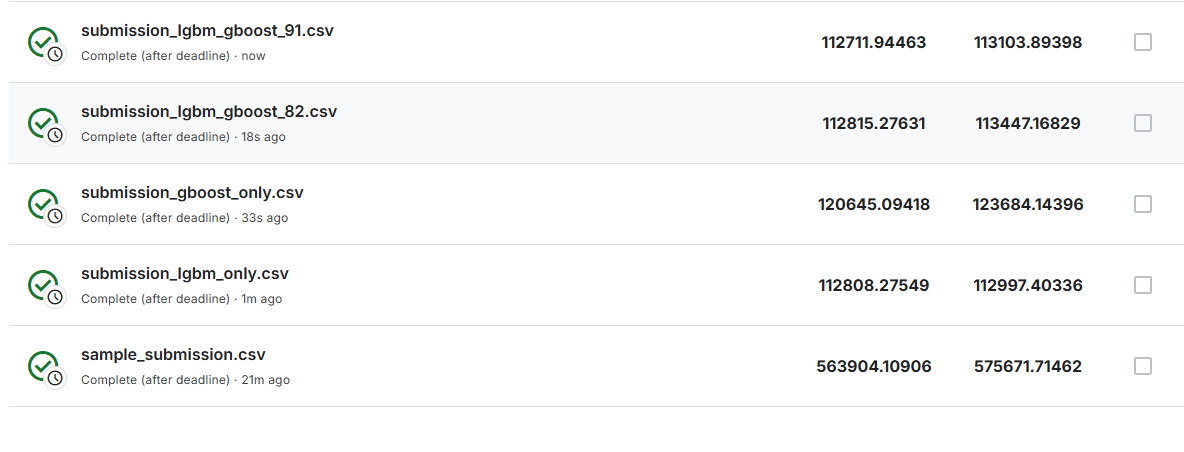

## 추가 실험: LGBM 기준 이상치 제거

현재 제출 결과를 비교한 결과, LGBM 계열 모델이 가장 안정적인 성능을 보였다.  
따라서 다음 단계에서는 모델 구조를 크게 바꾸기보다,  
LGBM 단일 모델을 기준으로 이상치를 제거한 데이터에서 다시 학습하여 성능 개선 가능성을 확인한다.

이번 실험의 목적은 다음과 같다.

1. 극단적으로 큰 집값이 모델 학습을 방해하는지 확인
2. 이상치 제거 후 LGBM 단일 성능이 개선되는지 확인
3. 개선된다면 이후 동일 데이터로 블렌딩까지 확장할지 판단

In [39]:
# ================================
# 추가 실험 A-1. 이상치 제거용 데이터 생성
# ================================

train_lgbm_out = train_fe.copy()
y_lgbm_out = y.copy()

# y는 log1p(price)이므로 원래 가격으로 복원
price_original = np.expm1(y_lgbm_out)

# 상위 극단값 제거
# 우선 300만 이상 제거부터 시작
mask_price = price_original < 3000000

train_lgbm_out = train_lgbm_out[mask_price]
y_lgbm_out = y_lgbm_out[mask_price]

print("원본 데이터 크기 :", train_fe.shape, y.shape)
print("이상치 제거 후 크기 :", train_lgbm_out.shape, y_lgbm_out.shape)
print("제거된 행 수 :", len(train_fe) - len(train_lgbm_out))

원본 데이터 크기 : (15035, 33) (15035,)
이상치 제거 후 크기 : (14999, 33) (14999,)
제거된 행 수 : 36


In [40]:
# ================================
# 추가 실험 A-2. 이상치 제거 후 LGBM 검증
# ================================

X_train_out, X_valid_out, y_train_out, y_valid_out = train_test_split(
    train_lgbm_out, y_lgbm_out, test_size=0.2, random_state=random_state
)

best_lgbm.fit(X_train_out, y_train_out)

pred_lgbm_out = best_lgbm.predict(X_valid_out)

rmse_lgbm_out = rmse(y_valid_out, pred_lgbm_out)

print("기존 LGBM RMSE :", rmse(y_valid, pred_lgbm))
print("이상치 제거 후 LGBM RMSE :", rmse_lgbm_out)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3851
[LightGBM] [Info] Number of data points in the train set: 11999, number of used features: 33
[LightGBM] [Info] Start training from score 13.043329
기존 LGBM RMSE : 111117.60309454468
이상치 제거 후 LGBM RMSE : 107356.0008752341


In [41]:
# ================================
# 추가 실험 A-3. 이상치 제거 버전 최종 학습 및 제출 파일 저장
# ================================

best_lgbm.fit(train_lgbm_out, y_lgbm_out)

pred_test_lgbm_out_log = best_lgbm.predict(test_fe)
pred_test_lgbm_out = np.expm1(pred_test_lgbm_out_log)

submission_lgbm_out = pd.read_csv(join(data_dir, 'sample_submission.csv'))
submission_lgbm_out['price'] = pred_test_lgbm_out

display(submission_lgbm_out.head())
print(submission_lgbm_out['price'].describe())

submission_lgbm_out.to_csv(join(data_dir, 'submission_lgbm_outlier_removed.csv'), index=False)
print("저장 완료: submission_lgbm_outlier_removed.csv")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3895
[LightGBM] [Info] Number of data points in the train set: 14999, number of used features: 33
[LightGBM] [Info] Start training from score 13.043106


,id,price
0,15035,5.035635e+05
1,15036,4.706906e+05
2,15037,1.452379e+06
3,15038,3.038921e+05
4,15039,3.329167e+05


count    6.468000e+03
mean     5.276427e+05
std      3.155301e+05
min      1.223333e+05
25%      3.203895e+05
50%      4.506440e+05
75%      6.307608e+05
max      3.207021e+06
Name: price, dtype: float64
저장 완료: submission_lgbm_outlier_removed.csv


## 추가 실험: 이상치 제거 데이터에서 LGBM + GBoost 9:1 검증

현재까지의 제출 결과에서 가장 우수한 조합은 LGBM + GBoost 9:1 이었다.  
따라서 이상치 제거 효과를 보다 정확히 확인하기 위해,  
단일 LGBM이 아니라 현재 최고 성능 조합인 LGBM + GBoost 9:1 기준으로 다시 검증한다.

이 실험의 목적은 다음과 같다.

1. 이상치 제거가 최고 성능 조합에서도 유효한지 확인
2. 단일 모델에서 나빠진 결과가 블렌드에서는 완화되는지 확인
3. 실제 제출 가치가 있는지 판단

In [42]:
# ================================
# 추가 실험 B-1. 이상치 제거 데이터로 LGBM + GBoost 9:1 검증
# ================================

X_train_out2, X_valid_out2, y_train_out2, y_valid_out2 = train_test_split(
    train_lgbm_out, y_lgbm_out, test_size=0.2, random_state=random_state
)

best_lgbm.fit(X_train_out2, y_train_out2)
best_gboost.fit(X_train_out2, y_train_out2)

pred_lgbm_out2 = best_lgbm.predict(X_valid_out2)
pred_gboost_out2 = best_gboost.predict(X_valid_out2)

blend_out2_91 = 0.9 * pred_lgbm_out2 + 0.1 * pred_gboost_out2

print("기존 최고 제출 기준(참고): 112711.94463")
print("이상치 제거 후 LGBM only 검증 RMSE :", rmse(y_valid_out2, pred_lgbm_out2))
print("이상치 제거 후 GBoost only 검증 RMSE :", rmse(y_valid_out2, pred_gboost_out2))
print("이상치 제거 후 LGBM+GBoost 9:1 검증 RMSE :", rmse(y_valid_out2, blend_out2_91))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3851
[LightGBM] [Info] Number of data points in the train set: 11999, number of used features: 33
[LightGBM] [Info] Start training from score 13.043329
기존 최고 제출 기준(참고): 112711.94463
이상치 제거 후 LGBM only 검증 RMSE : 107356.0008752341
이상치 제거 후 GBoost only 검증 RMSE : 118719.65897647677
이상치 제거 후 LGBM+GBoost 9:1 검증 RMSE : 107818.53001072316


In [43]:
# ================================
# 추가 실험 B-2. 이상치 제거 데이터로 LGBM + GBoost 9:1 제출 파일 생성
# ================================

best_lgbm.fit(train_lgbm_out, y_lgbm_out)
best_gboost.fit(train_lgbm_out, y_lgbm_out)

pred_test_lgbm_out2_log = best_lgbm.predict(test_fe)
pred_test_gboost_out2_log = best_gboost.predict(test_fe)

pred_test_blend_out2_91 = np.expm1(
    0.9 * pred_test_lgbm_out2_log + 0.1 * pred_test_gboost_out2_log
)

submission_lgbm_gboost_outlier_91 = pd.read_csv(join(data_dir, 'sample_submission.csv'))
submission_lgbm_gboost_outlier_91['price'] = pred_test_blend_out2_91

display(submission_lgbm_gboost_outlier_91.head())
print(submission_lgbm_gboost_outlier_91['price'].describe())

submission_lgbm_gboost_outlier_91.to_csv(
    join(data_dir, 'submission_lgbm_gboost_outlier_91.csv'),
    index=False
)

print("저장 완료: submission_lgbm_gboost_outlier_91.csv")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3895
[LightGBM] [Info] Number of data points in the train set: 14999, number of used features: 33
[LightGBM] [Info] Start training from score 13.043106


,id,price
0,15035,5.042201e+05
1,15036,4.651111e+05
2,15037,1.440808e+06
3,15038,3.046031e+05
4,15039,3.318790e+05


count    6.468000e+03
mean     5.273077e+05
std      3.143735e+05
min      1.247170e+05
25%      3.203587e+05
50%      4.508676e+05
75%      6.309535e+05
max      3.254902e+06
Name: price, dtype: float64
저장 완료: submission_lgbm_gboost_outlier_91.csv


***처참하게 실패했다.***

# 추가 피처 개선 실험

현재 최고 제출 결과는 `LGBM + GBoost 9:1` 조합에서 나왔다.  
그러나 목표 점수인 110000 이하에는 아직 도달하지 못했다.

이제부터는 이상치 제거가 아니라,  
입력 피처를 더 잘 표현하는 방향으로 추가 실험을 진행한다.

이번 실험의 목적은 다음과 같다.

1. 면적 계열 변수의 분포 왜곡을 줄이기 위해 로그 변환을 적용한다.
2. 집값에 중요한 조합 효과를 반영하기 위해 상호작용 피처를 추가한다.
3. 개선된 피처를 사용하여 LGBM + GBoost 9:1 조합을 다시 검증하고 제출 파일을 생성한다.

In [44]:
# ================================
# 추가 피처 실험 1. 원본 복사
# ================================

train_feat = train_fe.copy()
test_feat = test_fe.copy()

print("피처 개선 실험용 데이터 준비 완료")
print("train_feat shape:", train_feat.shape)
print("test_feat shape :", test_feat.shape)

피처 개선 실험용 데이터 준비 완료
train_feat shape: (15035, 33)
test_feat shape : (6468, 33)


In [45]:
# ================================
# 추가 피처 실험 2. 면적 계열 로그 변환
# ================================

log_cols = [
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot15',
    'total_sqft'
]

for col in log_cols:
    if col in train_feat.columns:
        train_feat[col] = np.log1p(train_feat[col])
        test_feat[col] = np.log1p(test_feat[col])

print("면적 계열 로그 변환 완료")
print(train_feat[log_cols].head())

면적 계열 로그 변환 완료
   sqft_living  sqft_lot  sqft_above  sqft_basement  sqft_living15  \
0     7.074117  8.639588    7.074117            0.0       7.201171   
1     6.647688  9.210440    6.647688            0.0       7.908755   
2     7.427144  8.997271    7.427144            0.0       7.496097   
3     7.447751  8.827615    7.447751            0.0       7.713785   
4     6.966967  9.181118    6.966967            0.0       7.409136   

   sqft_lot15  total_sqft  
0    8.639588    7.074117  
1    8.995041    6.647688  
2    8.923191    7.427144  
3    8.827615    7.447751  
4    9.181118    6.966967  


In [46]:
# ================================
# 추가 피처 실험 3. 상호작용 피처 추가
# ================================

# grade와 집 크기 조합
train_feat['grade_sqft'] = train_feat['grade'] * train_feat['sqft_living']
test_feat['grade_sqft'] = test_feat['grade'] * test_feat['sqft_living']

# 욕실 수와 등급 조합
train_feat['bath_grade'] = train_feat['bathrooms'] * train_feat['grade']
test_feat['bath_grade'] = test_feat['bathrooms'] * test_feat['grade']

# 위도와 등급 조합
train_feat['lat_grade'] = train_feat['lat'] * train_feat['grade']
test_feat['lat_grade'] = test_feat['lat'] * test_feat['grade']

# 전망과 등급 조합
train_feat['view_grade'] = train_feat['view'] * train_feat['grade']
test_feat['view_grade'] = test_feat['view'] * test_feat['grade']

# 리모델링 여부와 등급 조합
train_feat['reno_grade'] = train_feat['is_renovated'] * train_feat['grade']
test_feat['reno_grade'] = test_feat['is_renovated'] * test_feat['grade']

print("상호작용 피처 추가 완료")
print("추가된 컬럼:")
print(['grade_sqft', 'bath_grade', 'lat_grade', 'view_grade', 'reno_grade'])
print("현재 train_feat shape:", train_feat.shape)

상호작용 피처 추가 완료
추가된 컬럼:
['grade_sqft', 'bath_grade', 'lat_grade', 'view_grade', 'reno_grade']
현재 train_feat shape: (15035, 38)


## 추가 피처 설명

이번에 새로 적용한 피처는 크게 두 종류이다.

### 1. 로그 변환 피처
면적 관련 변수들은 값 범위가 넓고 한쪽으로 치우치기 쉽다.  
따라서 로그 변환을 적용해 큰 값의 영향을 줄이고,  
모델이 보다 안정적으로 패턴을 학습하도록 했다.

### 2. 상호작용 피처
집값은 단순히 각 변수의 합으로만 결정되지 않는다.  
예를 들어 같은 면적이라도 `grade`가 높으면 더 비싸고,  
같은 `grade`라도 `view`가 있으면 더 비쌀 수 있다.

따라서 다음과 같은 조합 피처를 추가했다.

- `grade_sqft`
- `bath_grade`
- `lat_grade`
- `view_grade`
- `reno_grade`

이 피처들은 개별 변수보다 더 직접적으로 집값 패턴을 설명할 가능성이 있다.

In [47]:
# ================================
# 추가 피처 실험 4. 검증 분리
# ================================

X_train_f, X_valid_f, y_train_f, y_valid_f = train_test_split(
    train_feat, y, test_size=0.2, random_state=random_state
)

print("검증용 분리 완료")
print(X_train_f.shape, X_valid_f.shape)

검증용 분리 완료
(12028, 38) (3007, 38)


In [48]:
# ================================
# 추가 피처 실험 5. LGBM + GBoost 9:1 검증
# ================================

best_lgbm.fit(X_train_f, y_train_f)
best_gboost.fit(X_train_f, y_train_f)

pred_lgbm_f = best_lgbm.predict(X_valid_f)
pred_gboost_f = best_gboost.predict(X_valid_f)

blend_pred_f_91 = 0.9 * pred_lgbm_f + 0.1 * pred_gboost_f
blend_pred_f_82 = 0.8 * pred_lgbm_f + 0.2 * pred_gboost_f

rmse_lgbm_f = rmse(y_valid_f, pred_lgbm_f)
rmse_gboost_f = rmse(y_valid_f, pred_gboost_f)
rmse_blend_f_91 = rmse(y_valid_f, blend_pred_f_91)
rmse_blend_f_82 = rmse(y_valid_f, blend_pred_f_82)

print("기존 최고 제출 점수(참고): 112711.94463")
print("새 피처 LGBM only RMSE        :", rmse_lgbm_f)
print("새 피처 GBoost only RMSE      :", rmse_gboost_f)
print("새 피처 LGBM+GBoost 9:1 RMSE  :", rmse_blend_f_91)
print("새 피처 LGBM+GBoost 8:2 RMSE  :", rmse_blend_f_82)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4478
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 38
[LightGBM] [Info] Start training from score 13.047779
기존 최고 제출 점수(참고): 112711.94463
새 피처 LGBM only RMSE        : 110335.65580730268
새 피처 GBoost only RMSE      : 118362.68735715156
새 피처 LGBM+GBoost 9:1 RMSE  : 110215.44928521002
새 피처 LGBM+GBoost 8:2 RMSE  : 110321.93788092934


In [49]:
# ================================
# 추가 피처 실험 6. 검증 결과 표
# ================================

feature_compare_df = pd.DataFrame({
    'model': [
        'LGBM_only_feature',
        'GBoost_only_feature',
        'LGBM_GBoost_91_feature',
        'LGBM_GBoost_82_feature'
    ],
    'RMSE': [
        rmse_lgbm_f,
        rmse_gboost_f,
        rmse_blend_f_91,
        rmse_blend_f_82
    ]
}).sort_values('RMSE', ascending=True).reset_index(drop=True)

display(feature_compare_df)

,model,RMSE
0,LGBM_GBoost_91_feature,110215.449285
1,LGBM_GBoost_82_feature,110321.937881
2,LGBM_only_feature,110335.655807
3,GBoost_only_feature,118362.687357


In [50]:
# ================================
# 추가 피처 실험 7. 전체 데이터로 최종 학습
# ================================

best_lgbm.fit(train_feat, y)
best_gboost.fit(train_feat, y)

print("새 피처 기준 전체 학습 완료")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4528
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 38
[LightGBM] [Info] Start training from score 13.048122
새 피처 기준 전체 학습 완료


In [51]:
# ================================
# 추가 피처 실험 8. 제출 파일 생성
# ================================

pred_test_lgbm_f_log = best_lgbm.predict(test_feat)
pred_test_gboost_f_log = best_gboost.predict(test_feat)

pred_test_lgbm_f = np.expm1(pred_test_lgbm_f_log)
pred_test_gboost_f = np.expm1(pred_test_gboost_f_log)
pred_test_blend_f_91 = np.expm1(0.9 * pred_test_lgbm_f_log + 0.1 * pred_test_gboost_f_log)
pred_test_blend_f_82 = np.expm1(0.8 * pred_test_lgbm_f_log + 0.2 * pred_test_gboost_f_log)

sample_sub = pd.read_csv(join(data_dir, 'sample_submission.csv'))

submission_lgbm_feature = sample_sub.copy()
submission_lgbm_feature['price'] = pred_test_lgbm_f
submission_lgbm_feature.to_csv(join(data_dir, 'submission_lgbm_feature.csv'), index=False)

submission_lgbm_gboost_feature_91 = sample_sub.copy()
submission_lgbm_gboost_feature_91['price'] = pred_test_blend_f_91
submission_lgbm_gboost_feature_91.to_csv(join(data_dir, 'submission_lgbm_gboost_feature_91.csv'), index=False)

submission_lgbm_gboost_feature_82 = sample_sub.copy()
submission_lgbm_gboost_feature_82['price'] = pred_test_blend_f_82
submission_lgbm_gboost_feature_82.to_csv(join(data_dir, 'submission_lgbm_gboost_feature_82.csv'), index=False)

print("제출 파일 저장 완료")
print(join(data_dir, 'submission_lgbm_feature.csv'))
print(join(data_dir, 'submission_lgbm_gboost_feature_91.csv'))
print(join(data_dir, 'submission_lgbm_gboost_feature_82.csv'))

제출 파일 저장 완료
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_feature.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_feature_91.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_feature_82.csv


In [52]:
# ================================
# 추가 피처 실험 9. 제출값 확인
# ================================

submission_summary_feature_df = pd.DataFrame({
    'file_name': [
        'submission_lgbm_feature.csv',
        'submission_lgbm_gboost_feature_91.csv',
        'submission_lgbm_gboost_feature_82.csv'
    ],
    'mean_price': [
        submission_lgbm_feature['price'].mean(),
        submission_lgbm_gboost_feature_91['price'].mean(),
        submission_lgbm_gboost_feature_82['price'].mean()
    ],
    'min_price': [
        submission_lgbm_feature['price'].min(),
        submission_lgbm_gboost_feature_91['price'].min(),
        submission_lgbm_gboost_feature_82['price'].min()
    ],
    'max_price': [
        submission_lgbm_feature['price'].max(),
        submission_lgbm_gboost_feature_91['price'].max(),
        submission_lgbm_gboost_feature_82['price'].max()
    ]
})

display(submission_summary_feature_df)

,file_name,mean_price,min_price,max_price
0,submission_lgbm_feature.csv,529837.898780,119177.082737,4.593698e+06
1,submission_lgbm_gboost_feature_91.csv,529409.868457,121529.618978,4.623401e+06
2,submission_lgbm_gboost_feature_82.csv,529003.574551,123928.593512,4.653296e+06


## 추가 피처 실험 정리

이번 실험에서는 기존 데이터를 삭제하지 않고 유지한 채,  
입력 피처의 표현력을 높이는 방향으로 개선을 시도했다.

구체적으로는 다음을 수행했다.

1. 면적 계열 변수 로그 변환
2. 등급, 욕실, 위치, 전망, 리모델링 여부와 관련된 상호작용 피처 추가
3. LGBM 및 LGBM + GBoost 9:1 조합 재검증
4. 여러 제출 파일 생성

이 실험의 결과를 기존 최고 제출 점수와 비교하여  
실제로 점수가 개선되는지 확인한다.

In [ ]:
# ================================
# 추가 실험 C-1. 학습량 증가 모델 정의
# ================================

lgbm_more = LGBMRegressor(
    random_state=random_state,
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)

gboost_more = GradientBoostingRegressor(
    random_state=random_state,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4
)

print("학습량 증가 모델 준비 완료")

## 또실패했다.추가 실험: 기존 최고 조합의 학습량 증가

현재까지 가장 좋은 제출 결과는 LGBM + GBoost 9:1 조합에서 나왔다.  
피처 추가와 이상치 제거는 성능 개선에 실패했으므로,  
이번에는 기존 조합을 유지한 채 모델 학습량을 늘려 성능 개선 가능성을 확인한다.

실험 목적은 다음과 같다.

1. 현재 피처 구성을 유지한다.
2. LGBM과 GBoost의 학습량을 소폭 증가시킨다.
3. LGBM + GBoost 9:1 조합에서 점수 개선 여부를 확인한다.

In [53]:
# ================================
# 추가 실험 C-1. 학습량 증가 모델 정의
# ================================

lgbm_more = LGBMRegressor(
    random_state=random_state,
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)

gboost_more = GradientBoostingRegressor(
    random_state=random_state,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4
)

print("학습량 증가 모델 준비 완료")

학습량 증가 모델 준비 완료


In [54]:
# ================================
# 추가 실험 C-2. 학습량 증가 버전 검증
# ================================

X_train_more, X_valid_more, y_train_more, y_valid_more = train_test_split(
    train_fe, y, test_size=0.2, random_state=random_state
)

lgbm_more.fit(X_train_more, y_train_more)
gboost_more.fit(X_train_more, y_train_more)

pred_lgbm_more = lgbm_more.predict(X_valid_more)
pred_gboost_more = gboost_more.predict(X_valid_more)

blend_more_91 = 0.9 * pred_lgbm_more + 0.1 * pred_gboost_more
blend_more_82 = 0.8 * pred_lgbm_more + 0.2 * pred_gboost_more

print("기존 참고 점수")
print("LGBM only            :", rmse(y_valid, pred_lgbm))
print("LGBM+GBoost 9:1      :", rmse(y_valid, blend_pred_f_91) if 'blend_pred_f_91' in globals() else "이전 변수 없음")

print("\n학습량 증가 버전")
print("LGBM more only       :", rmse(y_valid_more, pred_lgbm_more))
print("GBoost more only     :", rmse(y_valid_more, pred_gboost_more))
print("LGBM+GBoost more 9:1 :", rmse(y_valid_more, blend_more_91))
print("LGBM+GBoost more 8:2 :", rmse(y_valid_more, blend_more_82))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3855
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 33
[LightGBM] [Info] Start training from score 13.047779
기존 참고 점수
LGBM only            : 111117.60309454468
LGBM+GBoost 9:1      : 110215.44928521002

학습량 증가 버전
LGBM more only       : 109946.0112342036
GBoost more only     : 117810.6045624226
LGBM+GBoost more 9:1 : 109884.31447165938
LGBM+GBoost more 8:2 : 110029.55278092976


In [55]:
# ================================
# 추가 실험 C-3. 최종 제출 파일 생성
# ================================

lgbm_more.fit(train_fe, y)
gboost_more.fit(train_fe, y)

pred_test_lgbm_more_log = lgbm_more.predict(test_fe)
pred_test_gboost_more_log = gboost_more.predict(test_fe)

pred_test_blend_more_91 = np.expm1(
    0.9 * pred_test_lgbm_more_log + 0.1 * pred_test_gboost_more_log
)

pred_test_blend_more_82 = np.expm1(
    0.8 * pred_test_lgbm_more_log + 0.2 * pred_test_gboost_more_log
)

sample_sub = pd.read_csv(join(data_dir, 'sample_submission.csv'))

submission_more_91 = sample_sub.copy()
submission_more_91['price'] = pred_test_blend_more_91
submission_more_91.to_csv(join(data_dir, 'submission_lgbm_gboost_more_91.csv'), index=False)

submission_more_82 = sample_sub.copy()
submission_more_82['price'] = pred_test_blend_more_82
submission_more_82.to_csv(join(data_dir, 'submission_lgbm_gboost_more_82.csv'), index=False)

print("저장 완료")
print(join(data_dir, 'submission_lgbm_gboost_more_91.csv'))
print(join(data_dir, 'submission_lgbm_gboost_more_82.csv'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 33
[LightGBM] [Info] Start training from score 13.048122
저장 완료
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_more_91.csv
/home/jovyan/work/kaggle_kakr_housing/data/submission_lgbm_gboost_more_82.csv


In [110]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 42.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]


In [114]:
import os
import warnings
import pandas as pd
import numpy as np
import lightgbm as lgb
from os.path import join, exists
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

# =========================================================
# 1. 경로 설정
# =========================================================
data_dir = os.path.expanduser('~/work/kaggle_kakr_housing/data')

train_path = join(data_dir, 'train.csv')
test_path = join(data_dir, 'test.csv')
sample_submission_path = join(data_dir, 'sample_submission.csv')
output_path = join(data_dir, 'submission_final_stable.csv')

# =========================================================
# 2. 파일 존재 여부 확인
# =========================================================
required_files = [train_path, test_path]
for path in required_files:
    if not exists(path):
        raise FileNotFoundError(f"필수 파일이 없습니다: {path}")

# =========================================================
# 3. 데이터 로드
# =========================================================
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"train shape: {train.shape}")
print(f"test shape : {test.shape}")

# =========================================================
# 4. 타겟 분리
# =========================================================
if 'price' not in train.columns:
    raise ValueError("train.csv에 'price' 컬럼이 없습니다.")

if 'id' not in train.columns or 'id' not in test.columns:
    raise ValueError("train/test에 'id' 컬럼이 반드시 있어야 합니다.")

y = np.log1p(train['price'])
train_id = train['id'].copy()
test_id = test['id'].copy()

train = train.drop(columns=['price'])

# =========================================================
# 5. 피처 엔지니어링
# =========================================================
def transform_features(df):
    df = df.copy()

    # 위치 기반 파생변수
    luxury_lat, luxury_long = 47.62, -122.24
    if 'lat' in df.columns and 'long' in df.columns:
        df['dist_to_luxury'] = np.sqrt(
            (df['lat'] - luxury_lat) ** 2 + (df['long'] - luxury_long) ** 2
        )

    # 기본 파생변수
    if 'yr_built' in df.columns:
        df['house_age'] = 2015 - df['yr_built']

    if 'bedrooms' in df.columns and 'bathrooms' in df.columns:
        df['total_rooms'] = df['bedrooms'] + df['bathrooms']

    if 'sqft_living' in df.columns and 'sqft_lot' in df.columns:
        df['sqft_total'] = df['sqft_living'] + df['sqft_lot']

    # 날짜 처리
    if 'date' in df.columns:
        try:
            dt = pd.to_datetime(df['date'], errors='coerce')
            df['sale_year'] = dt.dt.year
            df['sale_month'] = dt.dt.month
            df['sale_day'] = dt.dt.day
        except Exception:
            pass

    # 불필요 컬럼 제거
    drop_cols = [col for col in ['id', 'date'] if col in df.columns]
    df = df.drop(columns=drop_cols, errors='ignore')

    return df

train = transform_features(train)
test = transform_features(test)

# =========================================================
# 6. 범주형 처리
# =========================================================
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)

cat_cols = all_data.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=False)

train = all_data.iloc[:len(train)].copy()
test = all_data.iloc[len(train):].copy()

print(f"transformed train shape: {train.shape}")
print(f"transformed test shape : {test.shape}")

# =========================================================
# 7. 평가 함수
# =========================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# 8. LightGBM OOF
# =========================================================
def train_lgb_oof(x_train, y_train, x_test, n_splits=5):
    oof_train = np.zeros(len(x_train))
    oof_test = np.zeros(len(x_test))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(x_train), 1):
        x_tr, x_val = x_train.iloc[tr_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(
            n_estimators=3000,
            learning_rate=0.02,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective='regression'
        )

        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        val_pred = model.predict(x_val)
        test_pred = model.predict(x_test)

        oof_train[val_idx] = val_pred
        oof_test += test_pred / n_splits

        print(f"[LGB Fold {fold}] RMSE: {rmse(y_val, val_pred):.6f}")

    total_rmse = rmse(y_train, oof_train)
    print(f"[LGB OOF RMSE] {total_rmse:.6f}")
    return oof_train, oof_test

# =========================================================
# 9. CatBoost OOF
# =========================================================
def train_cat_oof(x_train, y_train, x_test, n_splits=5):
    try:
        from catboost import CatBoostRegressor
    except ImportError:
        print("CatBoost가 설치되지 않았습니다. LightGBM 단독으로 진행합니다.")
        return None, None

    oof_train = np.zeros(len(x_train))
    oof_test = np.zeros(len(x_test))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(x_train), 1):
        x_tr, x_val = x_train.iloc[tr_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=3000,
            learning_rate=0.02,
            depth=7,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=42,
            verbose=0
        )

        model.fit(
            x_tr, y_tr,
            eval_set=(x_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100,
            verbose=False
        )

        val_pred = model.predict(x_val)
        test_pred = model.predict(x_test)

        oof_train[val_idx] = val_pred
        oof_test += test_pred / n_splits

        print(f"[CAT Fold {fold}] RMSE: {rmse(y_val, val_pred):.6f}")

    total_rmse = rmse(y_train, oof_train)
    print(f"[CAT OOF RMSE] {total_rmse:.6f}")
    return oof_train, oof_test

# =========================================================
# 10. 학습 및 앙상블
# =========================================================
lgb_oof, lgb_pred = train_lgb_oof(train, y, test)
cat_oof, cat_pred = train_cat_oof(train, y, test)

if cat_pred is not None:
    final_pred_log = 0.5 * lgb_pred + 0.5 * cat_pred
    print("최종 예측: LightGBM + CatBoost 5:5 앙상블")
else:
    final_pred_log = lgb_pred
    print("최종 예측: LightGBM 단독")

final_pred = np.expm1(final_pred_log)

# =========================================================
# 11. 제출 파일 생성
# =========================================================
if exists(sample_submission_path):
    submission = pd.read_csv(sample_submission_path)

    if 'price' not in submission.columns:
        submission['price'] = final_pred
    else:
        submission['price'] = final_pred

    if 'id' not in submission.columns:
        submission.insert(0, 'id', test_id.values)
else:
    print("sample_submission.csv가 없어서 test id 기준으로 제출 파일을 직접 생성합니다.")
    submission = pd.DataFrame({
        'id': test_id,
        'price': final_pred
    })

submission.to_csv(output_path, index=False)
print(f"제출 파일 생성 완료: {output_path}")
print(submission.head())

train shape: (15035, 21)
test shape : (6468, 20)
transformed train shape: (15035, 25)
transformed test shape : (6468, 25)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3002
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 25
[LightGBM] [Info] Start training from score 13.047364
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1576]	valid_0's rmse: 0.15928	valid_0's l2: 0.0253701
[LGB Fold 1] RMSE: 0.159280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3033
[LightGBM] [Info] Number of dat

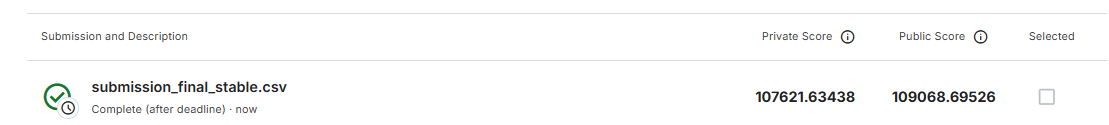